# CNN — Fashion MNIST
Convolutional classifier. Input reshaped to (N, 1, 28, 28). Two conv blocks → flatten → FC head.

## Setup

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## Data

In [3]:
CLASS_NAMES = ['T-shirt','Trouser','Pullover','Dress','Coat',
                'Sandal','Shirt','Sneaker','Bag','Ankle boot']

df = pd.read_csv('data/fashion_mnist.csv')
X = df.iloc[:, 1:].values / 255.0
y = df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (8000, 784), Test: (2000, 784)


## Dataset — Reshapes flat vector to (1, 28, 28)

In [4]:
class FashionDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32).reshape(-1, 1, 28, 28)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

train_loader = DataLoader(FashionDataset(X_train, y_train), batch_size=32, shuffle=True, pin_memory=True)
test_loader  = DataLoader(FashionDataset(X_test,  y_test),  batch_size=32, shuffle=False, pin_memory=True)

## Model
- Block 1: Conv(1→32) → ReLU → BN → MaxPool(2×2) → 14×14
- Block 2: Conv(32→64) → ReLU → BN → MaxPool(2×2) → 7×7
- Classifier: Flatten → FC(3136→128) → Dropout → FC(128→64) → Dropout → FC(64→10)

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

## Training

In [6]:
epochs = 30
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=1e-4, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(features), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    avg = total_loss / len(train_loader)
    train_losses.append(avg)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}  Loss: {avg:.4f}")

c:\Users\Hamid Raza Bajwa\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 5/30  Loss: 0.3960
Epoch 10/30  Loss: 0.2731
Epoch 15/30  Loss: 0.1565
Epoch 20/30  Loss: 0.1036
Epoch 25/30  Loss: 0.0565
Epoch 30/30  Loss: 0.0463


## Loss Curve

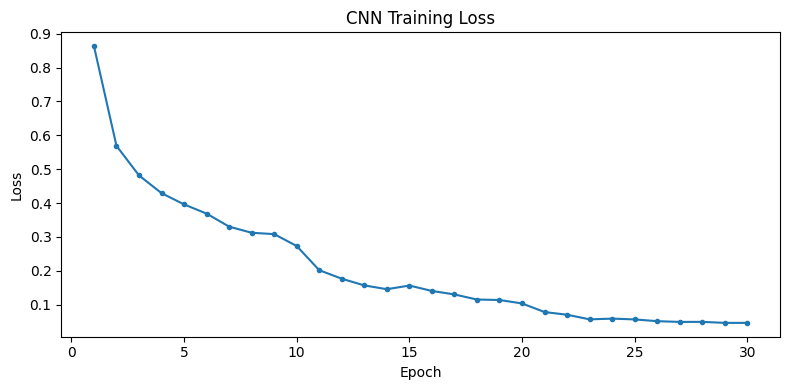

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), train_losses, marker='o', markersize=3)
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("CNN Training Loss")
plt.tight_layout(); plt.show()

## Evaluation

In [8]:
def evaluate(model, loader, name=""):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for features, labels in loader:
            features, labels = features.to(device), labels.to(device)
            _, predicted = torch.max(model(features), 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    acc = correct / total * 100
    print(f"{name} Accuracy: {acc:.2f}%")
    return acc

evaluate(model, train_loader, "Train")
evaluate(model, test_loader,  "Test")

Train Accuracy: 99.83%
Test Accuracy: 89.65%


89.64999999999999

## Per-Class Report

In [9]:
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device)
        _, preds = torch.max(model(features), 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

     T-shirt       0.84      0.80      0.82       192
     Trouser       0.98      0.97      0.98       192
    Pullover       0.82      0.89      0.85       212
       Dress       0.91      0.94      0.93       205
        Coat       0.88      0.81      0.84       204
      Sandal       0.96      0.99      0.97       193
       Shirt       0.71      0.72      0.72       200
     Sneaker       0.94      0.95      0.94       206
         Bag       0.97      0.97      0.97       196
  Ankle boot       0.97      0.93      0.95       200

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000



## Save Model

In [10]:
torch.save(model.state_dict(), 'cnn_fashion_mnist.pth')
print("Model saved.")

Model saved.
